#                         Product A/B Testing

### Project Overview
This project performs A/B testing on product data scraped from BooksToScrape.com..
The goal is to understand how product attributes (rating, price, title length) relate to each other and whether they influence pricing or perceived quality.


The dataset used in this analysis was scraped from BooksToScrape.com, a publicly available e‑commerce sandbox website containing 1000 book listings across 50 pages.

The goal of this project is to understand whether certain product characteristics influence pricing or perceived quality. By applying A/B testing, we can compare groups of products and determine whether differences between them are statistically significant.


### Web Scraping
This section shows how the dataset was collected from BooksToScrape.com , a publicly available e-commerce sandbox website .The site contains 1000 books spread across 50 pages , each page listing 20 product.
Each product card contain:
Title
Price
Rating

In [1]:
# Installing BeautifulSoup for web scraping
!pip install requests beautifulsoup4 pandas

In [3]:
#loading the libraries
import requests
from bs4 import BeautifulSoup
import pandas as pd
import seaborn as sns

#web scraping the data set
url ="https://books.toscrape.com/catalogue/page-1.html"
response = requests.get(url) # send an HTTP request
soup = BeautifulSoup(response.text,"html.parser") # parsing the HTML using BeautifulSoup


titles = []
prices = []
ratings = []

# looping throught the pages
#Extracting the title, price and rating of the book from
for product in soup.find_all("article", class_="product_pod"):
    title = product.h3.a["title"] # Located inside the<h3> tag
    price = product.find("p", class_="price_color").text # found inside the class tag
    rating = product.find("p")["class"][1] # Encode as a word inside the class name

    if product:
      titles.append(title)
      prices.append(price)
      ratings.append(rating)

# Storing inside the data frame
df = pd.DataFrame({
     "title" : titles,
     "price" : prices,
     "rating" : ratings

})

df.shape



(20, 3)

In [4]:
df.head(10)

,title,price,rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five
5,The Requiem Red,Â£22.65,One
6,The Dirty Little Secrets of Getting Your Dream...,Â£33.34,Four
7,The Coming Woman: A Novel Based on the Life of...,Â£17.93,Three
8,The Boys in the Boat: Nine Americans and Their...,Â£22.60,Four
9,The Black Maria,Â£52.15,One


## Data Cleaning

In [5]:
# convert price into numeric
df['price'] = (
    df['price']
    .str.replace('£','', regex=False)
    .str.replace('Â','', regex=False)
    .astype(float)
)

In [6]:
#mapping the rating to numeric

rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
    }

df['rating'] = df['rating'].map(rating_map)

df.head()

,title,price,rating
0,A Light in the Attic,51.77,3
1,Tipping the Velvet,53.74,1
2,Soumission,50.10,1
3,Sharp Objects,47.82,4
4,Sapiens: A Brief History of Humankind,54.23,5


## A/B Variants

In this section we are defining the control group and treatment group for each experiment by splitting the datatset.

* Control group = the baseline(Variant A)
* Treatment group = the new or alternative version(Variant B)

For this project ,three variants are created for three different experiment

Variant 1 = Rating based


*  A= Low rated books
*  B= High rated books

Variant 2 = Price-Based



*   A = Cheap books
*   B = Expensive books

Variant 3 = Title-Length Based


*   Short TItles
*   Long Titles















In [7]:
# Creating variants for Rating
df['variant_rating'] = df['rating'].apply( lambda x:'A' if x <= 3 else 'B')

In [8]:
#Creating variants for Rating
median_price = df['price'].median()

df['variant_price'] = df['price'].apply( lambda x:'A' if x < median_price else 'B' )

In [9]:
# Creating variants for title length
df['title_length'] = df['title'].apply(len)

df['variant_title'] = df['title_length'].apply ( lambda x:'A' if x < 40 else 'B')

## Hypothesis

This section states the null and alternative hypotheses for each A/B test.

Rating Based Variant



* H₀: No difference in average price between low-rated and high-rated books
* H₁: High-rated books are priced higher

Price Based Variant

* H₀: No difference in rating price between cheap and expensive books
* H₁: Expensive books are rated higher

Title Length Based : For this two hypotheses are made on price and rating

* H₀: No difference in price between short title and long title books
* H₁: Long titles are priced higher

## Defining the KPI

Each A/B test used different KPIs , so defining the KPI

In [26]:
# Average price KPI
df.groupby('variant_rating')['price']
df['variant_price'].value_counts()

,count
variant_price,
B,10
A,10


In [27]:
#Average rating
df.groupby('variant_price')['rating']
df['variant_price'].value_counts()

,count
variant_price,
B,10
A,10


In [29]:
df.groupby('variant_title')['rating']
df['variant_title'].value_counts()

,count
variant_title,
A,13
B,7


In [31]:
df.groupby('variant_title')['price']
df['variant_title'].value_counts()

,count
variant_title,
A,13
B,7


## Statistical Testing
A Welch's t-test is used in this project for A/B testing.T-test is used for the following reasons:
 - the data is continous
 - comparing the means pf the two group
 - the sample size of the two group are unequal
 - the variance between the two group are also unequal

For each A/B variant:
- the dataset in split into control(A) and Treatmen(B) group
- the appropriate KPI in this case the average price and average rating is selected
-the mean KPI is calculated
- the t-test is used to statistically compare the mean

In [13]:
# A/B testing for rating variant

from scipy.stats import ttest_ind

A = df[df.variant_rating == 'A']['price']
B = df[df.variant_rating == 'B']['price']

t_stat, p_value= ttest_ind(A, B, equal_var=False)

print("t_stat", t_stat)
print("p_value",p_value)

if p_value < 0.05:
 print("Result: Variant B performs significantly better. ")
else:
  print("Result: No significant difference.")



t_stat 0.6323893321767694
p_value 0.5360731462105276
Result: No significant difference.


The Ttest result = 0.63 which is close to 0 means the group are very similar

p-value = 0.53
Since p-value > 0.05 it fails to reject the null hypotheses.There is not statistical significant difference between the control and treatment group for average price KPI

In [16]:
#A/B testing for price variant

A = df[df.variant_price == 'A']['rating']
B = df[df.variant_price == 'B']['rating']

t_stat, p_value = ttest_ind(A, B, equal_var=False)

print("t_stat", t_stat)
print("p_value",p_value)

if p_value < 0.05:
 print("Result: Variant B performs significantly better. ")
else:
  print("Result: No significant difference.")


t_stat 0.4191717895493598
p_value 0.6800587305357267
Result: No significant difference.


The Ttest result = 0.49 which is close to 0 means the group are very similar

p-value = 0.68
Since p-value > 0.05 it fails to reject the null hypotheses.There is not statistical significant difference between the control and treatment group for average rating KPI

In [17]:
#A/B testing for title length variant

A = df[df.variant_title == 'A']['price']
B = df[df.variant_title == 'B']['price']

t_stat, p_value = ttest_ind(A, B, equal_var=False)

print("t_stat", t_stat)
print("p_value",p_value)

if p_value < 0.05:
 print("Result: Variant B performs significantly better. ")
else:
  print("Result: No significant difference.")


t_stat 0.9234240917526813
p_value 0.37589212769123415
Result: No significant difference.


In [18]:
#A/B testing for title length variant

A = df[df.variant_title == 'A']['rating']
B = df[df.variant_title == 'B']['rating']

t_stat, p_value = ttest_ind(A, B, equal_var=False)

print("t_stat", t_stat)
print("p_value",p_value)

if p_value < 0.05:
 print("Result: Variant B performs significantly better. ")
else:
  print("Result: No significant difference.")

t_stat -0.6493772222836307
p_value 0.5258063500070177
Result: No significant difference.


For both the test above the Ttest result is close to 0 and pvalue > 0.05 .Hence it fails to reject the null hypotheses and no significant difference


All A/B tests resulted in non significant p-values(p>0.05) indicating that none of the tested attributes -rating , price, or title length show meaningful differences between control and treatment groups.

## Visualizations

<Axes: xlabel='variant_rating', ylabel='price'>

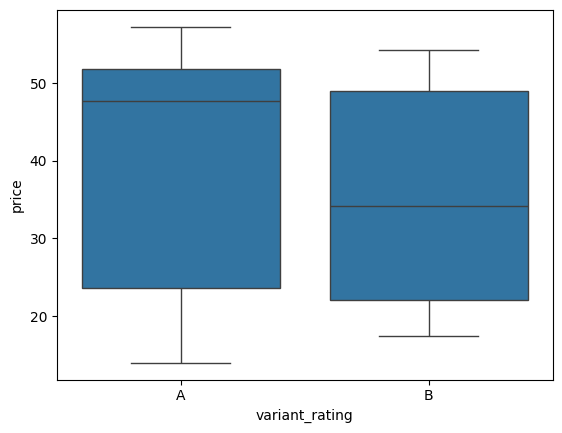

In [19]:
#Visualizing rating variant
sns.boxplot(data = df, x='variant_rating' , y='price')

<Axes: xlabel='variant_price', ylabel='rating'>

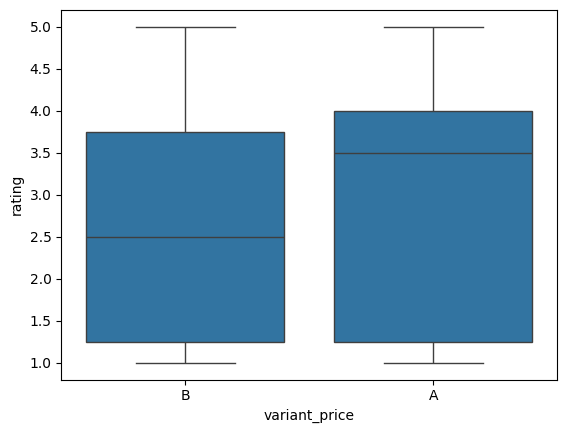

In [20]:
#Visualizing price variant
sns.boxplot(data = df, x='variant_price' , y='rating')

<Axes: xlabel='variant_title', ylabel='price'>

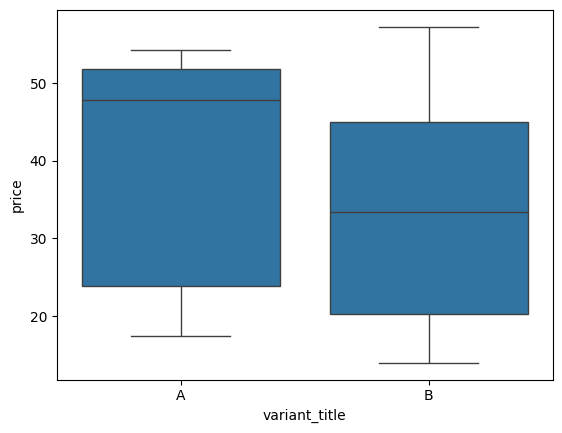

In [21]:
#Visualizing the title variant by Price KPI
sns.boxplot(data = df, x='variant_title' , y='price')

<Axes: xlabel='variant_title', ylabel='rating'>

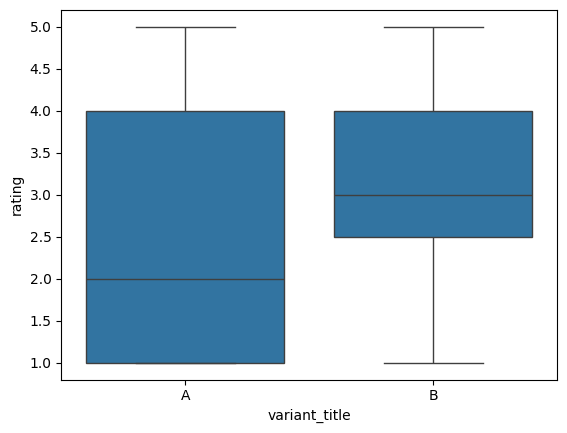

In [23]:
#Visualizing the title variant by rating KPI
sns.boxplot(data = df, x='variant_title' , y='rating')

## Business Interpretations

Across all three A/B test variants , the t-test results shows no statistically significant difference between the control and treatment group

1 Rating -Based Variant (Low vs High Rating)
Finding : High rated books are not priced higher than low rated books

Customers may not be willing to pay more for high rated books than low rated books

2. Price -based Variant( Cheap vs Expensive books)
Finding : Expensive books are not rated higher than cheap books
This suggest that pricing and perceived quality are not co related .Higher price does not gurantee higher customer satisfaction

3.Title-Length Variant(Short vs Long Titles)
Finding : Books with long titles do not have significantly different rating compares to books with short titles

Title length does not influence customer perception or rating.Customers likely judge books based on other factors(genre, author, cover etc)
